# NR Downlink System-Level Simulator (`nrsls`) — Guided Tour

A multi-cell, multi-UT **5G NR downlink system-level simulator** built on the
link-level simulator [`nrdlsim`](https://github.com/HelloSYQ/Claude). This
notebook walks through **every module**, explains what it models and which
3GPP / ITU-R specification it follows, runs a small live demo of each, and
ends with the **system-level validation test** against the 3GPP IMT-2020
self-evaluation (TR 37.910).

| Spec | Covers |
|------|--------|
| **TR 38.901** | deployment scenarios, pathloss, LOS, O2I, large-scale parameters, clusters and rays, antenna model |
| **ITU-R M.2412 / M.2410** | IMT-2020 test environments (Dense Urban, Rural, InH, …), channel model A/B, KPI definitions and requirements |
| **TS 38.211 / 38.214** | numerology, DM-RS, MCS/TBS, CSI (RI/PMI/CQI), Type-I and Rel-16 eType-II codebooks |
| **TR 37.910, RP-180524** | 3GPP calibration data and self-evaluation results used as references |

### What one drop does

```
 layout (hex grid + wrap-around)  ->  UT drop (indoor / in-car / outdoor)
   ->  pathloss, LOS, O2I, shadowing, 7 correlated LSPs        (TR 38.901 §7.4-7.5)
     ->  clusters and rays  ->  multipath coupling gain, attachment, geometry
       ->  per slot:  H(f, t) of the serving cell + K strongest interferers
             ->  CSI (RI / PMI: Type-I, eType-II, SVD / sub-band CQI), delayed
               ->  PF scheduler per RBG (SU, or MU pairing + RZF precoding)
                 ->  MMSE-IRC SINR  ->  MIESM -> BLER (nrdlsim)  ->  HARQ, OLLA
                   ->  KPIs: UT / cell spectral efficiency, BLER, rank, MCS
```

### Package map

| Module | Role |
|---|---|
| `config/scenario.py` | `ScenarioConfig`, BS / UT antenna configs, presets (`system`, `du-a`, `rp-*`, …) |
| `topology/` | hexagonal layout with wrap-around, InH hall, UT drop |
| `antenna/array.py` | panel + TXRU virtualisation, element pattern |
| `propagation/` | pathloss, LOS, O2I / car loss, LSPs, clusters and rays, channel synthesis H(f, t) |
| `link/` | noise, coupling gain, multipath port-0 RSRP, attachment, geometry |
| `engine/drop.py`, `engine/simulator.py` | one large-scale drop, multi-drop runner (spawned workers) |
| `phy/` | MMSE-IRC SINR, Type-I and eType-II codebooks, CSI processor |
| `mac/` | CQI → SINR → MCS, OLLA; MU-MIMO pairing and precoding |
| `engine/fullbuffer.py`, `engine/link.py` | the slot-level system loop (SU / MU), per-TB steps |
| `engine/single_link.py`, `validation/` | LLS ↔ SLS regression, the Dense Urban validation case |

## 0 · Environment setup

Find the repository root, import the package, and set a plot style that
matches the figures in `results/`.

In [1]:
import os, sys, json, time
_p = os.getcwd()
while _p != os.path.dirname(_p) and not os.path.isdir(os.path.join(_p, "nrsls")):
    _p = os.path.dirname(_p)
sys.path.insert(0, _p); os.chdir(_p)

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display
%matplotlib inline

from nrsls.plots import cdf as sty          # palette and axis style of the repo
from nrsls.metrics.kpi import ecdf
C = sty.SERIES                              # fixed categorical order
plt.rcParams.update({"figure.figsize": (8, 3.6), "figure.facecolor": sty.SURFACE,
                     "font.size": 9})

def style(ax, title=None, xlabel=None, ylabel=None):
    sty.style_axes(ax)
    if title: ax.set_title(title, loc="left", fontsize=10)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    return ax

import nrdlsim
print("working dir:", os.getcwd(), "| nrdlsim from", os.path.dirname(nrdlsim.__file__))

working dir: /home/user/NR_DL_SLS | nrdlsim from /home/user/.venv-sls/lib/python3.11/site-packages/nrdlsim


## 1 · `config/scenario.py` — scenarios and presets

A `ScenarioConfig` holds one deployment: layout, carrier, power, UT mix,
O2I model, BS/UT antennas and the propagation family. Presets cover the
default system (`system`: UMa 3.5 GHz, 100 MHz, 32T4R), the TR 38.901
scenarios, the RP-180524 calibration set-ups (`rp-*`) and the ITU-R M.2412
Dense Urban-eMBB configuration A used by the validation test (`du-a`).
Every field can be overridden: `get_preset("system", ue_per_cell=20)`.

In [2]:
from nrsls.config.scenario import PRESETS, get_preset
print("presets:", ", ".join(sorted(PRESETS)))

cfg = get_preset("du-a")
a = cfg.bs_antenna
print(f"\n{cfg.name}")
print(f"  ISD {cfg.isd_m:.0f} m, {cfg.carrier_freq_hz/1e9:.1f} GHz, "
      f"{cfg.carrier.n_size_grid} PRB @ {cfg.carrier.subcarrier_spacing_hz/1e3:.0f} kHz, "
      f"{cfg.bs_tx_power_dbm:.0f} dBm, UT NF {cfg.ue_noise_figure_db:.0f} dB")
print(f"  gNB (M,N,P;Mp,Np) = ({a.M},{a.N},{a.P};{a.Mp},{a.Np}) -> {a.n_ports} ports, "
      f"UT {cfg.ue_antenna.n_ports} ports, {cfg.ue_per_cell} UTs/cell")
print(f"  {cfg.indoor_ratio:.0%} indoor ({cfg.ue_speed_kmh:.0f} km/h), outdoor in car "
      f"({cfg.in_car_speed_kmh:.0f} km/h), O2I '{cfg.o2i_model}' "
      f"({cfg.o2i_high_loss_ratio:.0%} high-loss)")

presets: calib-inh, calib-uma, calib-umi, du-a, inh-mixed, inh-open, rma, rp-inh-12trxp, rp-inh-36trxp, rp-mmtc-1732m, rp-mmtc-500m, rp-rural-4g, rp-rural-700m, rp-rural-lmlc, rp-urllc-4g, rp-urllc-700m, system, uma, umi

Dense Urban-eMBB A (FDD 10 MHz)
  ISD 200 m, 4.0 GHz, 52 PRB @ 15 kHz, 41 dBm, UT NF 7 dB
  gNB (M,N,P;Mp,Np) = (8,8,2;2,8) -> 32 ports, UT 4 ports, 10 UTs/cell
  80% indoor (3 km/h), outdoor in car (30 km/h), O2I 'mixed' (20% high-loss)


## 2 · `topology/` — hexagonal layout, wrap-around, UT drop

19 sites × 3 sectors (57 cells) on a hexagonal grid. **Wrap-around** gives
every UT the closest of 7 copies of each site, so edge cells see the same
interference as the centre. UTs are dropped uniformly per cell. An indoor
UT gets a floor (`h = 3(n_fl − 1) + 1.5 m`), an indoor distance and a
building type; an outdoor UT may sit in a car.

19 sites, 57 cells, 7 wrap-around copies, 570 UTs: 79% indoor, 21% in car


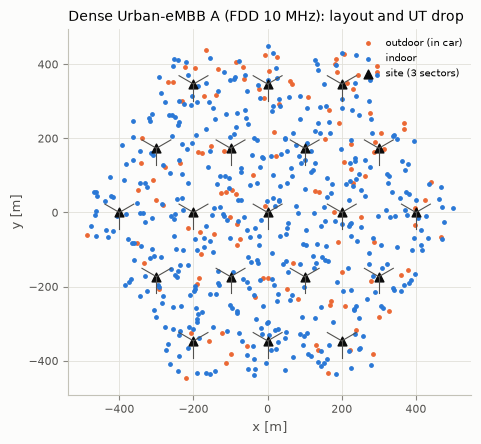

In [3]:
from nrsls.topology.layout import build_layout
from nrsls.topology.ue_drop import drop_ues

lay = build_layout(cfg)
ues = drop_ues(cfg, lay, np.random.default_rng(1))
print(f"{lay.n_sites} sites, {lay.n_cells} cells, {len(lay.wrap_offsets)} wrap-around copies, "
      f"{ues.n} UTs: {ues.o2i.mean():.0%} indoor, {ues.in_car.mean():.0%} in car")

fig, ax = plt.subplots(figsize=(5.2, 4.8))
ax.scatter(*ues.xy[~ues.o2i].T, s=6, color=C[1], label="outdoor (in car)")
ax.scatter(*ues.xy[ues.o2i].T, s=6, color=C[0], label="indoor")
ax.scatter(*lay.site_xy.T, marker="^", s=40, color=sty.INK, label="site (3 sectors)")
for s, (x, y) in enumerate(lay.site_xy):
    for b in lay.cell_bearing_deg[lay.cell_site == s]:
        ax.plot([x, x + 45 * np.cos(np.deg2rad(b))], [y, y + 45 * np.sin(np.deg2rad(b))],
                color=sty.INK_2, lw=0.8)
ax.set_aspect("equal"); ax.legend(fontsize=7, frameon=False, loc="upper right")
style(ax, f"{cfg.name}: layout and UT drop", "x [m]", "y [m]");

## 3 · `antenna/array.py` — panel and TXRU virtualisation

The gNB panel is (M, N, P) = (8, 8, 2) elements. Each TXRU feeds a vertical
sub-array of M/Mp = 4 elements, tilted electrically (102° = 12° down), so
one port is the TR 38.901 element pattern (8 dBi, 65°, 30 dB front-back)
times the sub-array factor. The 32 TXRUs (Mp × Np × P = 2 × 8 × 2) are the
CSI-RS ports the codebooks work on.

peak port gain 14.0 dBi


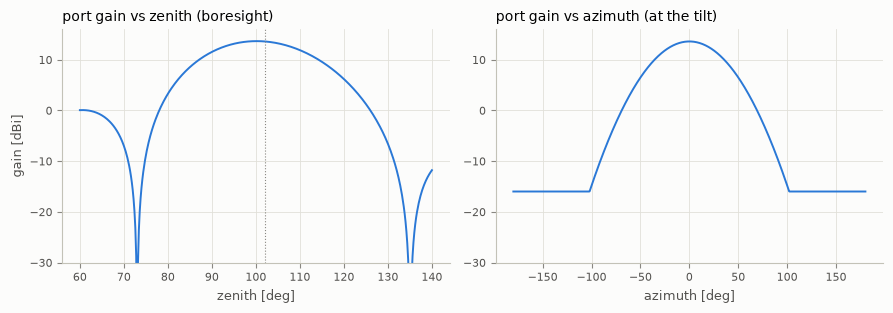

In [4]:
from nrsls.antenna.array import BSAntenna
ant = BSAntenna(cfg.bs_antenna)
zen = np.linspace(60, 140, 401); az = np.linspace(-180, 180, 721)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 3.2))
a1.plot(zen, ant.port_gain_db(np.zeros_like(zen), zen, bearing_deg=0.0), color=C[0], lw=1.4)
a1.axvline(cfg.bs_antenna.electrical_tilt_deg, color=sty.MUTED, lw=0.8, ls=":")
style(a1, "port gain vs zenith (boresight)", "zenith [deg]", "gain [dBi]"); a1.set_ylim(-30, 16)
a2.plot(az, ant.port_gain_db(az, np.full_like(az, cfg.bs_antenna.electrical_tilt_deg), bearing_deg=0.0),
         color=C[0], lw=1.4)
style(a2, "port gain vs azimuth (at the tilt)", "azimuth [deg]"); a2.set_ylim(-30, 16)
plt.tight_layout()
print(f"peak port gain {ant.peak_gain_dbi:.1f} dBi")

## 4 · `propagation/` — pathloss, LOS, O2I

TR 38.901 Table 7.4.1-1 pathloss with the Table 7.4.2-1 LOS probability.
Indoor UTs add the O2I loss (Table 7.4.3-2: low-loss / high-loss
buildings + an indoor distance), in-car UTs a N(9, 5) dB car loss. ITU-R
M.2412 departures are implemented where needed (LMLC rural, InH_A).

building wall loss at 4 GHz: low-loss 12.9 dB, high-loss 28.0 dB


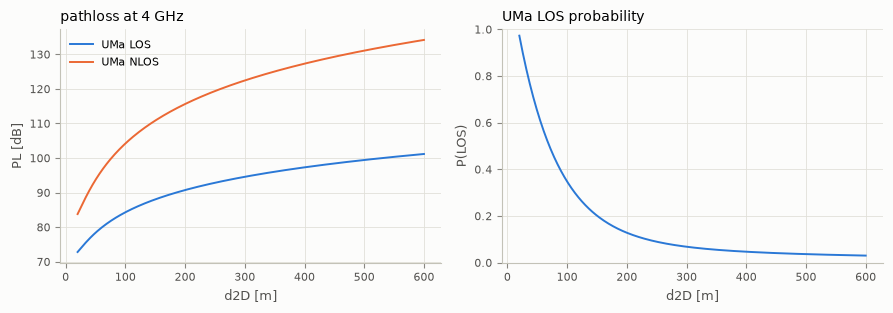

In [5]:
from nrsls.propagation.pathloss import uma_los, uma_nlos
from nrsls.propagation.los import los_probability
from nrsls.propagation.o2i import wall_loss_db

d2d = np.linspace(20, 600, 300); d3d = np.hypot(d2d, 25 - 1.5); fc = 4e9
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 3.2))
a1.plot(d2d, uma_los(d2d, d3d, 25, 1.5, fc), color=C[0], lw=1.4, label="UMa LOS")
a1.plot(d2d, uma_nlos(d2d, d3d, 25, 1.5, fc), color=C[1], lw=1.4, label="UMa NLOS")
a1.legend(fontsize=8, frameon=False); style(a1, "pathloss at 4 GHz", "d2D [m]", "PL [dB]")
a2.plot(d2d, los_probability("UMa", d2d), color=C[0], lw=1.4)
style(a2, "UMa LOS probability", "d2D [m]", "P(LOS)"); a2.set_ylim(0, 1)
plt.tight_layout()
print(f"building wall loss at 4 GHz: low-loss {wall_loss_db(4.0, False):.1f} dB, "
      f"high-loss {wall_loss_db(4.0, True):.1f} dB")

## 5 · `engine/drop.py`, `link/` — large-scale drop and calibration

`generate_drop` combines layout, UTs, pathloss, shadowing, the seven
spatially correlated LSPs (SF, K, DS, ASD, ASA, ZSD, ZSA), clusters and
rays. It then computes the **multipath coupling gain** of every (cell, UT)
link: port-0 power summed over all rays with the antenna gain in each
ray's direction (TR 36.873 eq. 8.1-1). UTs attach to the strongest cell,
and the **geometry** is the wideband SINR with all cells transmitting.

Phase 2 calibrated this against the RP-180524 per-company data (TR 37.910
Annex A) in all 9 configurations it covers. Below is a live check for one of
them, UMa URLLC 4 GHz: 6 drops against the company mean and the company
envelope (`docs/calibration-p2.md` has all of them).

6 drops, 3420 UTs, 16 s
coupling_gain_db  gap to the company mean at the p5/p10/p20/p50/p80/p90/p95 points: -0.9, -0.5, -0.2, -0.0, +0.1, -0.1, -0.2 dB
geometry_db       gap to the company mean at the p5/p10/p20/p50/p80/p90/p95 points: -0.2, -0.3, -0.3, -0.5, -0.9, -1.1, -0.9 dB


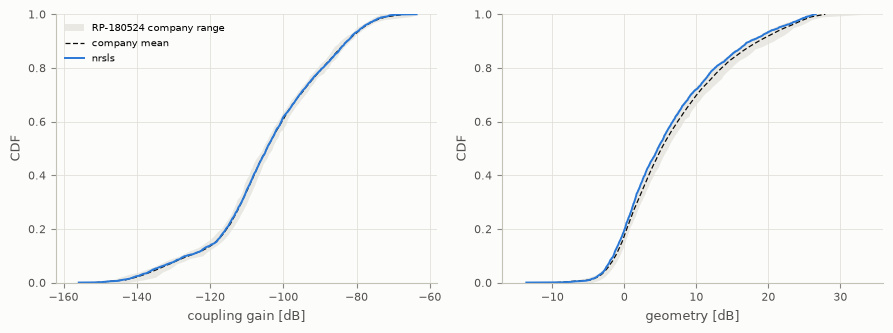

In [6]:
from nrsls.engine.simulator import run_large_scale
from nrsls.metrics.calibration import percentile_gaps
import csv

def ref_curves(name):
    rows = [r for r in csv.reader(open(f"refs/rp180524/{name}.csv")) if r and not r[0].startswith("#")]
    d = np.array([[float(x) for x in r[:4]] for r in rows[1:]])   # pct, mean, min, max
    return d[:, 0] / 100, d[:, 1], d[:, 2], d[:, 3]

t0 = time.time()
st = run_large_scale(get_preset("rp-urllc-4g"), n_drops=6, seed=1, n_jobs=1)
print(f"6 drops, {len(st.geometry_db)} UTs, {time.time()-t0:.0f} s")

fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
for ax, key, ref, xl in [(axes[0], "coupling_gain_db", "UMa_URLLC_4GHz_ModelA_coupling_gain", "coupling gain [dB]"),
                         (axes[1], "geometry_db", "UMa_URLLC_4GHz_ModelA_geometry", "geometry [dB]")]:
    p, mean, lo, hi = ref_curves(ref)
    ax.fill_betweenx(p, lo, hi, color=sty.GRID, alpha=0.7, lw=0, label="RP-180524 company range")
    ax.plot(mean, p, color=sty.INK, lw=0.9, ls=(0, (4, 2)), label="company mean")
    x, f = ecdf(getattr(st, key)); ax.plot(x, f, color=C[0], lw=1.4, label="nrsls")
    g = percentile_gaps(getattr(st, key), mean, p)
    print(f"{key:17s} gap to the company mean at the "
          + "/".join(str(k) for k in g) + " points: "
          + ", ".join(f"{v:+.1f}" for v in g.values()) + " dB")
    style(ax, None, xl, "CDF"); ax.set_ylim(0, 1)
axes[0].legend(fontsize=7, frameon=False, loc="upper left")
plt.tight_layout()

## 6 · `propagation/fast_fading.py` — the MIMO channel H(f, t)

For the slot loop the drop keeps every link's clusters. `channel_batch`
synthesises H[f, u, s] (UT ports × gNB ports) per frequency point and slot
for many links at once. It sums the rays of each sub-cluster with their
polarised antenna fields and Doppler phases first, then forms H(f) over
at most 3N delays. That is equal to the ray-level reference
(`link_channel`) to about 1e-6, and much faster.

UT 0: serving cell 0, geometry 14.6 dB, DS 130 ns, ASD 14 deg, H (52, 4, 32)


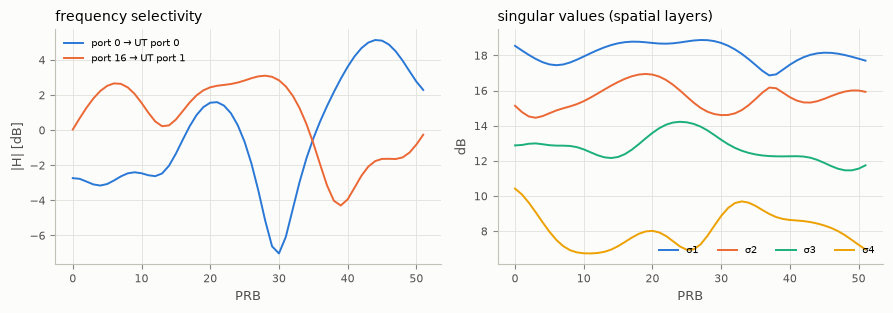

In [7]:
from nrsls.engine.drop import generate_drop
from nrsls.propagation.fast_fading import channel_batch, subset_clusters

d = generate_drop(cfg, np.random.default_rng(2), keep_clusters=True)
u = int(np.argmax(d.geometry_db > 10))                # a UT with good geometry
c = d.serving_cell[u]; s = d.layout.cell_site[c]
n_rb = cfg.carrier.n_size_grid; scs = cfg.carrier.subcarrier_spacing_hz
f_hz = (np.arange(n_rb) - (n_rb - 1) / 2) * 12 * scs
H = channel_batch(subset_clusters(d.clusters[s], [u]), d.layout.cell_bearing_deg[[c]],
                  cfg.bs_antenna, cfg.ue_antenna, f_hz, 0.0, np.zeros((1, 3)),
                  3e8 / cfg.carrier_freq_hz, d.d3d_m[s, [u]])[0]        # (F, 4, 32)
H = H / np.sqrt(np.mean(np.abs(H) ** 2))              # unit average gain per port pair
print(f"UT {u}: serving cell {c}, geometry {d.geometry_db[u]:.1f} dB, "
      f"DS {d.lsps.ds_s[s, u]*1e9:.0f} ns, ASD {d.lsps.asd_deg[s, u]:.0f} deg, H {H.shape}")

sv = np.linalg.svd(H, compute_uv=False)               # (F, 4)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 3.2))
a1.plot(np.arange(n_rb), 20 * np.log10(np.abs(H[:, 0, 0])), color=C[0], lw=1.4, label="port 0 → UT port 0")
a1.plot(np.arange(n_rb), 20 * np.log10(np.abs(H[:, 1, 16])), color=C[1], lw=1.4, label="port 16 → UT port 1")
a1.legend(fontsize=7, frameon=False); style(a1, "frequency selectivity", "PRB", "|H| [dB]")
for k in range(4):
    a2.plot(np.arange(n_rb), 20 * np.log10(sv[:, k]), color=C[k], lw=1.4, label=f"σ{k+1}")
a2.legend(fontsize=7, frameon=False, ncol=4); style(a2, "singular values (spatial layers)", "PRB", "dB")
plt.tight_layout()

## 7 · `phy/` — IRC SINR, Type-I and eType-II codebooks, CSI

* `sinr.py`: the UT whitens its channel with the interference-plus-noise
  covariance (MMSE-IRC); per-layer SINR of the whitened effective channel
  G = H̃W is 1/[(I + GᴴG)⁻¹]ₗₗ − 1.
* `codebook/type1.py`: TS 38.214 §5.2.2.2.1 Type-I single panel, ranks
  1–4, codebook mode 1, wideband i1 + sub-band co-phasing i2.
* `codebook/etype2.py`: Rel-16 eType-II §5.2.2.2.5. Per layer it uses L
  orthogonal DFT beams, M_v of N3 frequency-domain basis vectors and at
  most K0 non-zero coefficients, with a 4-bit reference amplitude, 3-bit
  differential amplitudes and 16-PSK phases. The payload is counted per
  report.
* `csi.py`: per report it picks the rank (RI), the PMI and the wideband
  and sub-band CQI. The CQI comes from MIESM over the layer SINRs of the
  *quantised* precoder. `svd` / `svd_sb` / `svd_rb` are ideal-CSI references.

Below: CSI of the channel from §6 at 15 dB SNR with each report type, the
precoder's achievable rate (with the reported rank), and the PMI payload.

In [8]:
from nrsls.phy.csi import CSIProcessor
from nrsls.phy.sinr import mmse_sinr, capacity

hw = H * 10 ** (15 / 20)                              # whitened, noise = 1
sb = np.arange(n_rb) // 4                             # 4-PRB sub-bands (N3 = 13)
print(f"{'report':9s} {'RI':>3s} {'CQI':>4s} {'PMI bits':>9s} {'rate [bit/RE]':>14s}")
for cbk in ["type1", "etype2", "svd", "svd_sb"]:
    proc = CSIProcessor(8, 2, codebook=cbk, max_rank=4, n_re_per_rb=132)
    rep = proc.select(hw, sb, 1, slot=0)
    w = rep.w[sb] if rep.w.ndim == 3 else rep.w
    rate = np.mean(capacity(hw @ w))
    print(f"{cbk:9s} {rep.rank:3d} {rep.cqi_wb:4d} {rep.pmi_bits:9d} {rate:14.2f}")

report     RI  CQI  PMI bits  rate [bit/RE]


type1       3   12        23          22.28
etype2      3   12       533          23.71
svd         3   13         0          24.07
svd_sb      4   12         0          30.01


## 8 · `mac/` — link adaptation and MU-MIMO

* `link_adaptation.py`: the gNB turns a reported CQI back into the SINR
  at which it meets 10 % BLER. It combines the sub-bands of an allocation,
  subtracts the UT's **OLLA** offset (+0.5 dB per NACK, −0.5·0.1/0.9 dB per
  ACK) and picks the highest MCS whose own 10 %-BLER SINR fits.
* `mu_mimo.py`: from the reports, the gNB models each layer as
  g = √(s·r)·v. That is the reported direction v scaled by the SU CQI SINR s
  and the UT's rank r.
  - **Precoding:** regularised ZF (MMSE precoding) W = Gᴴ(GGᴴ + L·I)⁻¹, or
    plain ZF, with equal power per layer.
  - **MU-SINR estimate:** from the same model.
  - **Pairing:** greedy per RBG. The PF owner opens the set, and UTs are
    added while Σ log₂(1+SINR)/R̄ grows. Limits: ≤ 6 UTs, ≤ 12 layers,
    rank ≤ 2.

mean |v_i^H v_j| between reported layers: 0.65
co-scheduled set: [0, 2, 1] (UT 3, aligned with UT 0, is left out)
per-layer MU SINR estimates [dB]: [12.2 12.2 12.2 12.2 12.2 12.2]


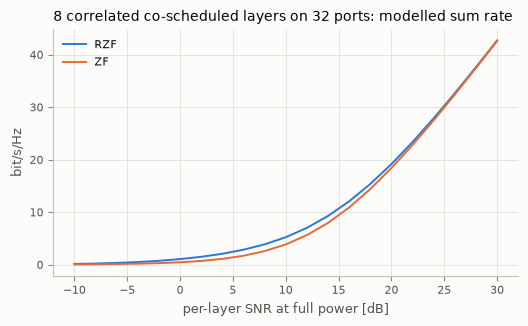

In [9]:
from nrsls.mac.mu_mimo import mu_precode, greedy_pairing, unit_columns

rng = np.random.default_rng(0)
cn = lambda *sh: rng.normal(size=sh) + 1j * rng.normal(size=sh)
common = cn(32, 1)                        # UTs in similar directions: correlated reports
v = unit_columns(common + 0.7 * cn(32, 8))
print("mean |v_i^H v_j| between reported layers:",
      np.round(np.mean(np.abs(v.conj().T @ v)[~np.eye(8, dtype=bool)]), 2))
snr_db = np.arange(-10, 31, 2)
fig, ax = plt.subplots(figsize=(6, 3.2))
for col, m in zip(C, ["rzf", "zf"]):
    rate = [np.sum(np.log2(1 + mu_precode(v, np.full(8, 10 ** (x / 10)), m)[1])) for x in snr_db]
    ax.plot(snr_db, rate, color=col, lw=1.4, label=m.upper())
ax.legend(fontsize=8, frameon=False)
style(ax, "8 correlated co-scheduled layers on 32 ports: modelled sum rate",
      "per-layer SNR at full power [dB]", "bit/s/Hz")

# pairing: UTs 1 and 2 orthogonal to UT 0, UT 3 almost aligned with it
q, _ = np.linalg.qr(rng.normal(size=(32, 8)) + 1j * rng.normal(size=(32, 8)))
vv = {0: q[:, :2], 1: q[:, 2:4], 2: q[:, 4:6],
      3: unit_columns(q[:, :2] + 0.05 * (rng.normal(size=(32, 2)) + 1j * rng.normal(size=(32, 2))))}
group, w, est, uid = greedy_pairing(0, [1, 2, 3], vv, {k: 50.0 for k in vv}, {k: 2 for k in vv},
                                    {k: 1.0 for k in vv}, 6, 12, method="rzf")
print("co-scheduled set:", group, "(UT 3, aligned with UT 0, is left out)")
print("per-layer MU SINR estimates [dB]:", np.round(10 * np.log10(est), 1))

## 9 · `engine/fullbuffer.py` — the slot-level system loop

Per drop the loop picks the serving cell plus the K strongest interferers
as explicit MIMO links; the other cells add wideband interference. Every
slot it:

1. **Schedules** each cell: HARQ retransmissions first, then PF per RBG. In
   SU mode the PF owner of an RBG gets the whole RBG; in MU mode it opens a
   co-scheduled set.
2. **Whitens** each UT's channel with the interference of the precoders its
   neighbours actually use.
3. **Decodes** every TB: MMSE SINR over the cell's layers, then MIESM →
   BLER → ACK/NACK, chase combining and OLLA.
4. **Collects CSI** every `csi_period_slots`, usable `csi_delay_slots`
   later.

A small live run follows: the RP-180524 URLLC 4 GHz layout with an 8-port
array, 4 UTs per cell and 40 slots, comparing SU and MU on the same drop.
Forty slots are too few for OLLA to converge, so expect BLER above the 10 %
target here; the 200-slot runs in §11 hold it.
The full-scale runs (57 cells × 10 UTs, 200 slots, 4 drops) take 10–20
minutes per configuration on 4 cores; their results are in §11.

In [10]:
import dataclasses
from nrsls.engine.fullbuffer import FullBufferConfig, run_full_buffer_drop

small = get_preset("rp-urllc-4g", ue_per_cell=4)
small = dataclasses.replace(small, bs_antenna=dataclasses.replace(small.bs_antenna, N=4, Np=4))
base = dict(n_slots=40, warmup_slots=20, k_interferers=2, codebook="svd", max_rank=2)
print(f"{'mode':4s} {'cell SE':>8s} {'5%-ile':>7s} {'BLER':>6s} {'UTs/RBG':>8s} {'layers/RBG':>11s} {'time':>6s}")
for name, kw in [("SU", {}), ("MU", dict(mu_mimo=True))]:
    t0 = time.time()
    r = run_full_buffer_drop(small, FullBufferConfig(**base, **kw), np.random.default_rng(5))
    print(f"{name:4s} {r.cell_se:8.2f} {np.percentile(r.ue_se, 5):7.3f} {r.bler_first:6.3f} "
          f"{r.mean_ues_per_rbg:8.2f} {r.mean_layers_per_rbg:11.2f} {time.time()-t0:5.0f}s")

mode  cell SE  5%-ile   BLER  UTs/RBG  layers/RBG   time


SU       3.27   0.187  0.201     1.00        1.55     4s


MU       4.10   0.170  0.138     2.42        3.38     8s


## 10 · `validation/lls.py` — LLS ↔ SLS single-link regression

The system loop's link chain (CSI, link adaptation, TB decode) must
reproduce the link-level simulator. `sls_point` runs one SLS link
(`engine/single_link.py`, the same code objects as the system loop) on
exactly the `nrdlsim` CDL channel that `run_point` uses. The ports are
re-ordered to the TS 38.214 CSI-RS order, and the CSI / HARQ settings are
matched. `tests/test_lls_regression.py` requires agreement within 4 %. The
full sweep agrees within 2 % over CDL-A/C/D, 4T2R–32T4R and −5…30 dB.

  SNR   LLS SE   SLS SE    diff   BLER LLS/SLS
    0     2.82     2.82   -0.0%  0.087/0.089
   10     7.57     7.59   +0.2%  0.093/0.094
   20    14.09    14.26   +1.2%  0.093/0.089


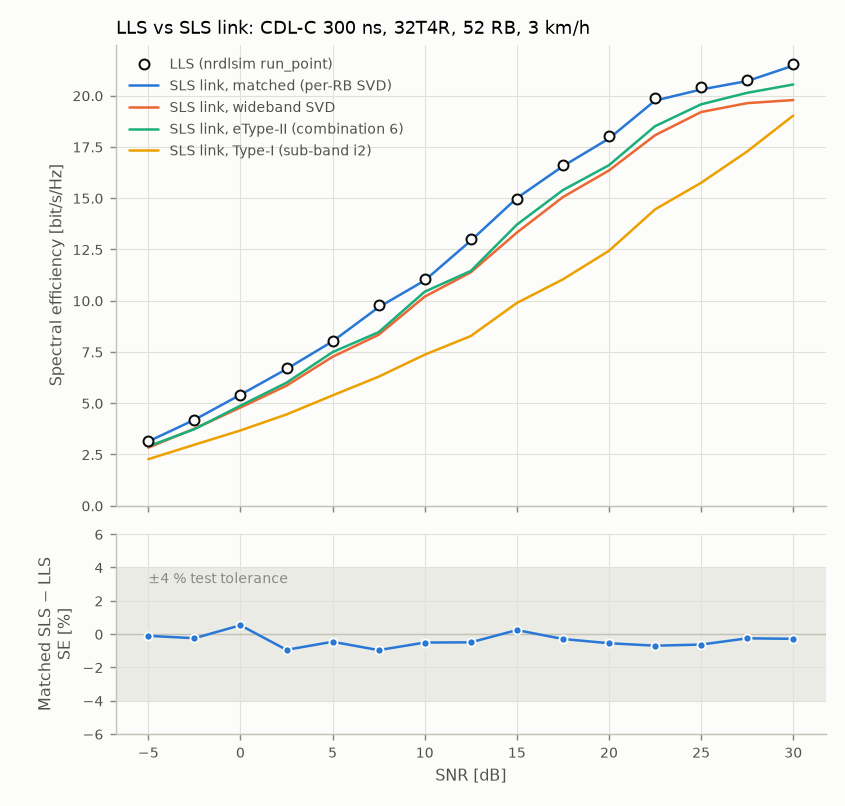

In [11]:
from nrsls.validation.lls import lls_config, matched_fb, sweep
cfg_l = lls_config(n1=4, n2=1, n_rx=4, n_rb=24, model="CDL-C", delay_spread_ns=300.0, n_slots=200)
out = sweep(cfg_l, [0.0, 10.0, 20.0], {"lls": None, "sls": matched_fb(cfg_l)})
print(f"{'SNR':>5s} {'LLS SE':>8s} {'SLS SE':>8s} {'diff':>7s} {'BLER LLS/SLS':>14s}")
for l, s_ in zip(out["lls"], out["sls"]):
    print(f"{l['snr_db']:5.0f} {l['se']:8.2f} {s_['se']:8.2f} {100*(s_['se']/l['se']-1):+6.1f}% "
          f"{l['bler']:6.3f}/{s_['bler']:.3f}")
display(Image("results/p3_lls_regression.png", width=560))

## 11 · Full-scale results (saved runs)

These come from the `examples/` scripts (4 drops × 200 slots, 2280 UTs per
configuration); the JSON files in `results/` hold the KPIs and the per-UT
samples. Two system set-ups:

* **UMa 3.5 GHz, 100 MHz, 32T4R** (`system`): SU-MIMO (phase 3) and
  MU-MIMO, Type-I / eType-II / SVD reports.
* **Dense Urban-eMBB A, FDD 10 MHz** (`du-a`): the TR 37.910 benchmark set-up.

UMa SU-MIMO  (UMa 3.5 GHz 32T4R, 4 drops)
  report    cell SE  5%-ile  median   BLER  UTs/RBG
  type1        5.83   0.192   0.508  0.117     1.00
  etype2       6.13   0.213   0.531  0.116     1.00
  svd          6.27   0.209   0.542  0.115     1.00
UMa MU-MIMO  (UMa 3.5 GHz 32T4R, 4 drops)
  report    cell SE  5%-ile  median   BLER  UTs/RBG
  type1        8.20   0.225   0.613  0.123     4.45
  etype2       9.83   0.288   0.756  0.098     5.19
  svd          9.88   0.269   0.729  0.102     4.90
Dense Urban A SU-MIMO  (Dense Urban-eMBB A (FDD 10 MHz), 4 drops)
  report    cell SE  5%-ile  median   BLER  UTs/RBG
  etype2       4.75   0.204   0.426  0.150     1.00
  type1        4.49   0.178   0.406  0.147     1.00
  svd_sb       5.05   0.211   0.444  0.151     1.00
Dense Urban A MU-MIMO  (Dense Urban-eMBB A (FDD 10 MHz), 4 drops)
  report    cell SE  5%-ile  median   BLER  UTs/RBG
  etype2       9.82   0.362   0.833  0.099     5.64
  type1        7.59   0.241   0.613  0.123     4.88
  sv

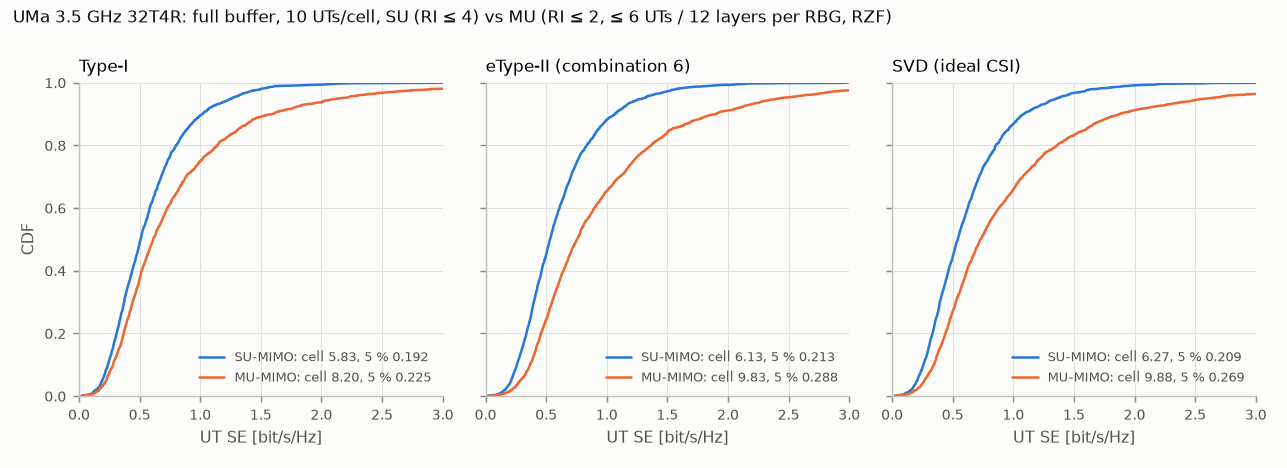

In [12]:
def table(path, title):
    j = json.load(open(path)); rows = j["results"]
    print(f"{title}  ({j['config']['preset']}, {j['config']['drops']} drops)")
    print(f"  {'report':8s} {'cell SE':>8s} {'5%-ile':>7s} {'median':>7s} {'BLER':>6s} {'UTs/RBG':>8s}")
    for k, v in rows.items():
        print(f"  {k:8s} {v['cell_se']:8.2f} {v['ue_se_p5']:7.3f} {v['ue_se_p50']:7.3f} "
              f"{v['bler_first']:6.3f} {v.get('mean_ues_per_rbg', 1):8.2f}")

table("results/p3_full_buffer.json", "UMa SU-MIMO")
table("results/p4_mu_full_buffer.json", "UMa MU-MIMO")
table("results/du_su_full_buffer.json", "Dense Urban A SU-MIMO")
table("results/du_mu_full_buffer.json", "Dense Urban A MU-MIMO")
display(Image("results/p4_su_vs_mu_cdf.png", width=900))

## 12 · The validation test — Dense Urban-eMBB A against TR 37.910

`nrsls/validation/du_a.py` defines one system-level case, its published
reference and pass/fail criteria.

**Case.** The ITU-R M.2412 Dense Urban-eMBB evaluation configuration A
(macro layer):
- 57 TRxPs at 200 m ISD, 4 GHz, FDD 10 MHz (52 PRB at 15 kHz), 41 dBm;
- gNB (8,8,2,1,1;2,8) = 32 TXRUs;
- 10 four-port UTs per TRxP, 80 % indoor at 3 km/h and 20 % in car at 30 km/h;
- full buffer, overhead included, MU-MIMO with the simulator defaults.

Two report types run on the same drops: **eType-II** (under test) and
**ideal per-sub-band CSI** (upper bound).

**Reference.** TR 37.910 Table 5.4.1.2.1-1(a), the 3GPP self-evaluation for
exactly this case: *32x4 MU-MIMO, Type II codebook, gNB (8,8,2,1,1;2,8)*,
10 MHz, averaged over 11 companies. The values are
**11.04 bit/s/Hz/TRxP** average and **0.37 bit/s/Hz** at the 5th percentile.

In [13]:
from nrsls.validation import du_a
print(du_a.REFERENCE["source"])
print("reference:", du_a.REFERENCE["avg_se"], "/", du_a.REFERENCE["p5_se"],
      "   ITU-R M.2410 requirement:", du_a.ITU_M2410["avg_se"], "/", du_a.ITU_M2410["p5_se"])
cfg_v, fb_v = du_a.case("etype2")
print(f"\ncase: {cfg_v.name}; codebook {fb_v.codebook}, RI <= {fb_v.max_rank}, MU {fb_v.mu_mimo} "
      f"({fb_v.mu_precoder.upper()}, <= {fb_v.mu_max_ues} UTs / {fb_v.mu_max_layers} layers), "
      f"CSI every {fb_v.csi_period_slots} ms + {fb_v.csi_delay_slots} ms delay, "
      f"{fb_v.pdcch_symbols} PDCCH symbols, {fb_v.overhead_re_per_prb} RE/PRB CSI-RS/SSB/TRS")

3GPP TR 37.910 Table 5.4.1.2.1-1(a): NR FDD, Dense Urban-eMBB config A, 32x4 MU-MIMO, Type II, (8,8,2,1,1;2,8), 15 kHz, channel model A, 10 MHz (11 companies)
reference: 11.04 / 0.37    ITU-R M.2410 requirement: 7.8 / 0.225

case: Dense Urban-eMBB A (FDD 10 MHz); codebook etype2, RI <= 2, MU True (RZF, <= 6 UTs / 12 layers), CSI every 5 ms + 4 ms delay, 2 PDCCH symbols, 9 RE/PRB CSI-RS/SSB/TRS


### Acceptance criteria

| Check | Pass if | Why |
|---|---|---|
| V1 | eType-II average SE within ±15 % of 11.04 | agreement with the 3GPP companies |
| V2 | eType-II 5th-percentile SE within ±15 % of 0.37 | same, at the cell edge |
| V3 | ideal-CSI average SE ≥ 0.95 × 11.04 | a bound below the companies' result would mean a loss elsewhere (geometry, power, overhead, scheduler) |
| V4 | ideal CSI > eType-II (average and 5th percentile) | better CSI must not do worse |
| V5 | eType-II ≥ 7.8 and ≥ 0.225 | the ITU-R M.2410 requirement the reference was made for |
| V6 | first-transmission BLER 0.07–0.13 | link adaptation holds its 10 % target |
| V7 | ≥ 2 co-scheduled UTs per RBG | the case exercises MU-MIMO |

The TR publishes the company average only, not its spread. The ±15 %
tolerance is about ±1 dB of SINR at these spectral efficiencies, which is
the inter-company spread of the RP-180524 calibration.

### The recorded run

The full case (2 drops × 200 slots, both report types) takes about 27 min
on 4 cores:

```bash
python examples/validate_du_a.py            # prints the table, exit code 1 on failure
NRSLS_SLOW=1 pytest tests/test_validation_du_a.py -s
```

Its KPIs are saved in `results/validation_du_a.json`. Here the criteria are
re-evaluated on them:

In [14]:
rec = json.load(open("results/validation_du_a.json"))
r = rec["results"]
checks = du_a.evaluate(r)
display(Markdown(du_a.report(r, checks)))

Dense Urban-eMBB A, FDD 10 MHz, 32x4 MU-MIMO: 2 drops x 200 slots (40 warm-up), seed 1, 1597 s

| Report | Average SE | 5th pct | Median | 1st-tx BLER | UTs / layers per RBG |
|---|---|---|---|---|---|
| etype2 | 9.77 | 0.358 | 0.823 | 0.099 | 5.65 / 11.17 |
| svd_sb | 12.59 | 0.445 | 1.049 | 0.094 | 5.77 / 11.50 |

Reference: 3GPP TR 37.910 Table 5.4.1.2.1-1(a): NR FDD, Dense Urban-eMBB config A, 32x4 MU-MIMO, Type II, (8,8,2,1,1;2,8), 15 kHz, channel model A, 10 MHz (11 companies): 11.04 / 0.37

| Check | Description | Measured | Criterion | Result |
|---|---|---|---|---|
| V1 | eType-II average SE vs TR 37.910 Type II | 9.77 (-11.5 %) | 11.04 ± 15 % | PASS |
| V2 | eType-II 5th-percentile SE vs TR 37.910 Type II | 0.358 (-3.2 %) | 0.37 ± 15 % | PASS |
| V3 | ideal-CSI bound not below the reference | 12.59 | >= 10.49 | PASS |
| V4 | ideal CSI > eType-II (average and 5th percentile) | 12.59 > 9.77, 0.445 > 0.358 | both | PASS |
| V5 | ITU-R M.2410 requirement with eType-II | 9.77 / 0.358 | >= 7.8 / >= 0.225 | PASS |
| V6 | first-transmission BLER (target 10 %) | 0.099 / 0.094 | 0.07 ... 0.13 | PASS |
| V7 | MU-MIMO exercised (co-scheduled UTs per RBG) | 5.65 / 5.77 | >= 2 | PASS |

**PASS** (7/7 checks)

### Does the test catch faults?

A test is only useful if it fails when something is wrong. Below, the
recorded KPIs are perturbed the way typical regressions would change them,
and the criteria are evaluated again:

* **CSI chain −10 %:** eType-II MU throughput drops 10 %, for example a
  codebook or pairing bug.
* **Power/overhead error:** every SE value drops 25 %, for example a wrong
  transmit power or an overhead counted twice.
* **Ideal CSI worse than the codebook:** a precoder or estimate bug that
  inverts the expected order.
* **Link adaptation off:** BLER at 25 %, for example a broken OLLA.
* **MU disabled:** the scheduler never co-schedules.

In [15]:
import copy

def perturb(f):
    x = copy.deepcopy(r); f(x); return x

def scale(x, cb, k):
    for key in ("cell_se", "ue_se_p5", "ue_se_p50"):
        x[cb][key] *= k

cases = {
    "as recorded": perturb(lambda x: None),
    "CSI chain -10 %": perturb(lambda x: scale(x, "etype2", 0.90)),
    "power/overhead error (-25 %)": perturb(lambda x: [scale(x, cb, 0.75) for cb in du_a.CODEBOOKS]),
    "ideal CSI worse than codebook": perturb(lambda x: scale(x, "svd_sb", 0.75)),
    "link adaptation off (BLER 25 %)": perturb(lambda x: x["etype2"].update(bler_first=0.25)),
    "MU disabled": perturb(lambda x: [x[cb].update(mean_ues_per_rbg=1.0) for cb in du_a.CODEBOOKS]),
}
print(f"{'scenario':34s} {'verdict':8s} failed checks")
for name, x in cases.items():
    ch = du_a.evaluate(x); bad = [c.id for c in ch if not c.passed]
    print(f"{name:34s} {'PASS' if not bad else 'FAIL':8s} {', '.join(bad) or '-'}")

scenario                           verdict  failed checks
as recorded                        PASS     -
CSI chain -10 %                    FAIL     V1
power/overhead error (-25 %)       FAIL     V1, V2, V3, V5
ideal CSI worse than codebook      FAIL     V3, V4
link adaptation off (BLER 25 %)    FAIL     V6
MU disabled                        FAIL     V7


Every injected fault turns the verdict to FAIL, and the failed checks
point at the broken stage.

The margin on V1 is deliberately small. The recorded eType-II result is
11.5 % below the reference, so a loss of about 4 % in the eType-II MU chain
fails V1. A uniform power or overhead error shows in V1, V2, V3 and V5 at
once.

### The Dense Urban result in context

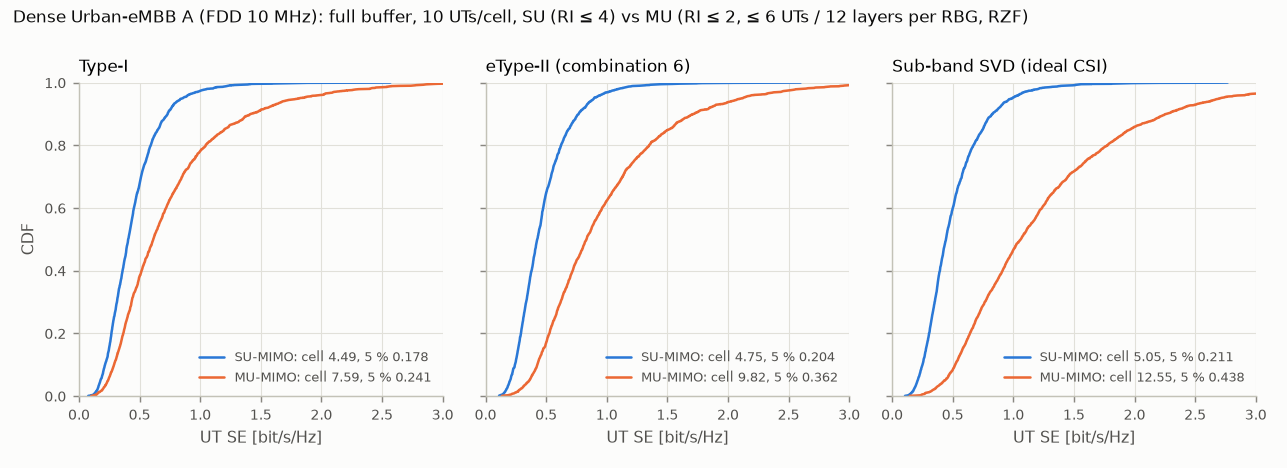

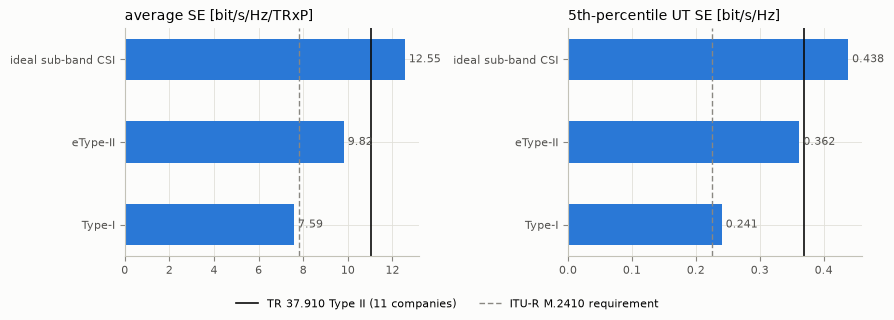

In [16]:
mu = json.load(open("results/du_mu_full_buffer.json"))["results"]
labels = {"type1": "Type-I", "etype2": "eType-II", "svd_sb": "ideal sub-band CSI"}
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 3.2))
for ax, key, ref, req, title in [(a1, "cell_se", 11.04, 7.8, "average SE [bit/s/Hz/TRxP]"),
                                 (a2, "ue_se_p5", 0.37, 0.225, "5th-percentile UT SE [bit/s/Hz]")]:
    vals = [mu[k][key] for k in labels]
    ax.barh(list(labels.values()), vals, color=C[0], height=0.5)
    ax.axvline(ref, color=sty.INK, lw=1.2, label="TR 37.910 Type II (11 companies)")
    ax.axvline(req, color=sty.MUTED, lw=1.0, ls=(0, (4, 2)), label="ITU-R M.2410 requirement")
    for y, v in enumerate(vals):
        ax.text(v, y, f" {v:.2f}" if key == "cell_se" else f" {v:.3f}", va="center", fontsize=8, color=sty.INK_2)
    style(ax, title)
h, l = a1.get_legend_handles_labels()
fig.legend(h, l, fontsize=8, frameon=False, loc="lower center", ncol=2)
plt.tight_layout(rect=(0, 0.08, 1, 1))
display(Image("results/du_su_vs_mu_cdf.png", width=900))

## 13 · Summary and where to go next

| Level | Check | Result |
|---|---|---|
| Geometry / channel | RP-180524 per-company coupling gain and geometry (9 configurations) | within ±1.5 dB of the company mean (`docs/calibration-p2.md`) |
| Link chain | LLS ↔ SLS single link, CDL-A/C/D, 4T2R–32T4R, −5…30 dB | within 2 % SE (`docs/lls-regression.md`) |
| System | Dense Urban-eMBB A vs TR 37.910 (validation test) | **PASS 7/7**: eType-II 9.77 / 0.358, ideal CSI 12.59 / 0.445 around the 11.04 / 0.37 reference (`docs/validation-du-a.md`) |

Documents: `docs/module-plan.md` (design), `docs/calibration-p1.md`,
`docs/calibration-p2.md`, `docs/results-p3.md`, `docs/results-p4-mu.md`,
`docs/lls-regression.md`, `docs/benchmark-tr37910.md`,
`docs/validation-du-a.md`.

Open items: FTP traffic models (UPT vs load), a non-ideal channel-estimation
option, and multi-panel / port-selection codebooks.